# Enerji Tüketimi Veri Analizi (EDA)

Bu çalışmada:
- Veri yapısı incelenecek
- Enerji tüketimi analiz edilecek
- Zaman bazlı davranış gözlemlenecek
- Anomaliye aday noktalar incelenecek

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [22]:
df = pd.read_csv("../data/raw/energydata_complete.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.set_index("date", inplace=True)

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9         

In [24]:
df.isnull().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


Veri setinde eksik değer bulunmamaktadır.

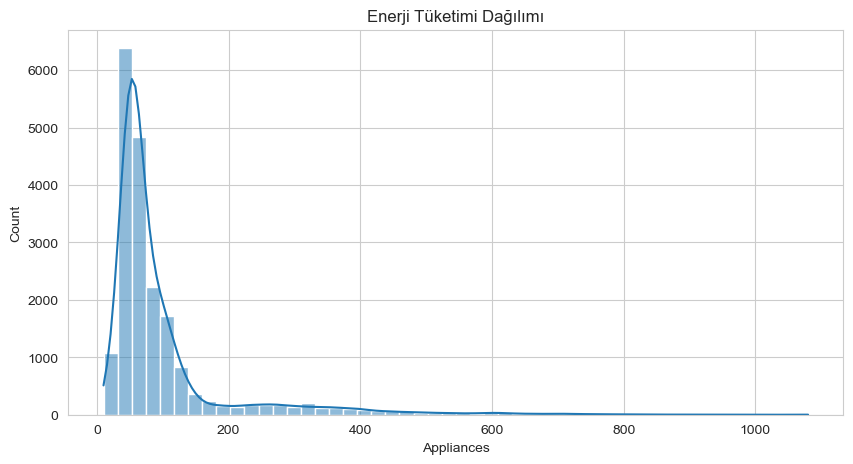

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(df["Appliances"], bins=50, kde=True)
plt.title("Enerji Tüketimi Dağılımı")
plt.show()

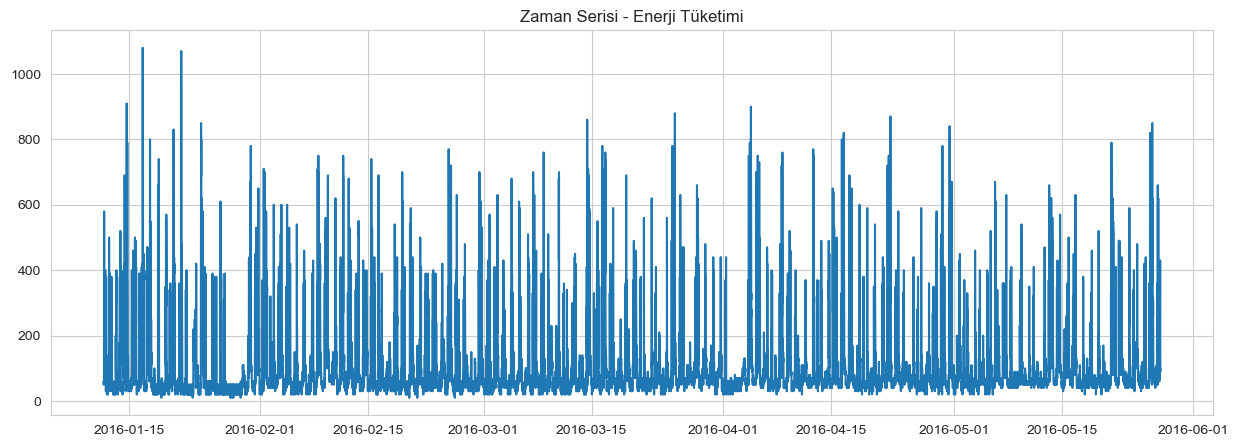

In [27]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Appliances"])
plt.title("Zaman Serisi - Enerji Tüketimi")
plt.show()

Enerji tüketimi zaman içinde dalgalıdır ve bazı ani artışlar gözlemlenmektedir.

In [29]:
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.dayofweek
df["Is_Weekend"] = df["DayOfWeek"].isin([5,6]).astype(int)

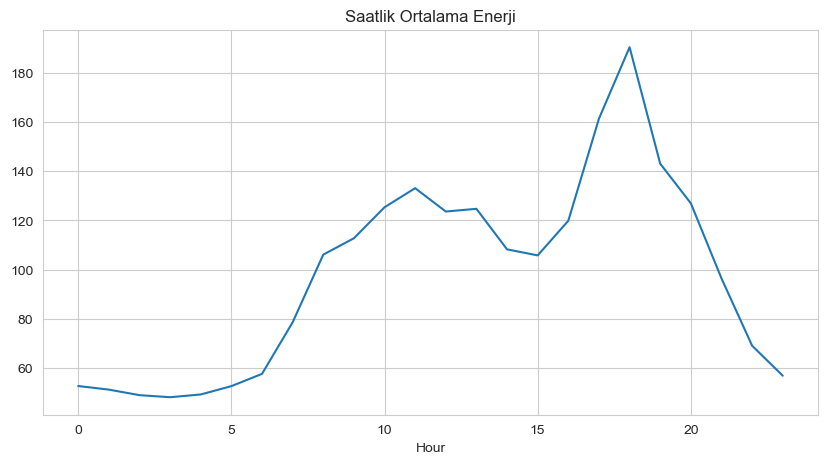

In [30]:
hourly_mean = df.groupby("Hour")["Appliances"].mean()

plt.figure(figsize=(10,5))
hourly_mean.plot()
plt.title("Saatlik Ortalama Enerji")
plt.show()

Gün içinde belirli saatlerde enerji tüketimi artmaktadır.

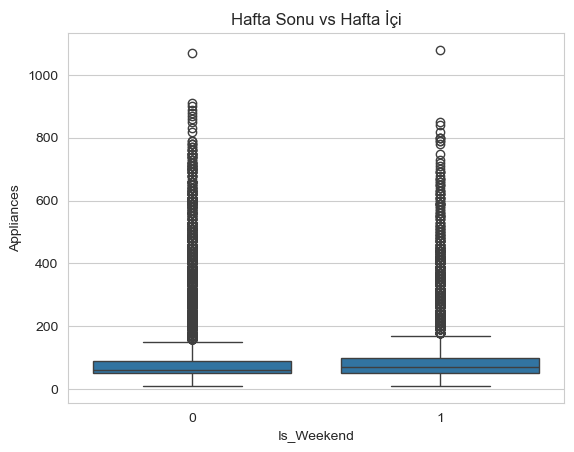

In [31]:
sns.boxplot(x="Is_Weekend", y="Appliances", data=df.reset_index())
plt.title("Hafta Sonu vs Hafta İçi")
plt.show()

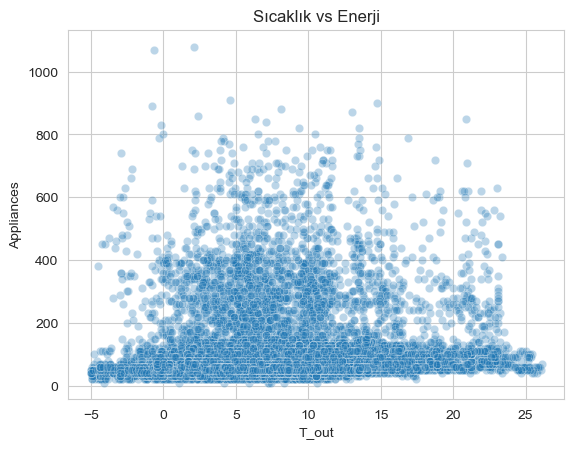

In [32]:
sns.scatterplot(x=df["T_out"], y=df["Appliances"], alpha=0.3)
plt.title("Sıcaklık vs Enerji")
plt.show()

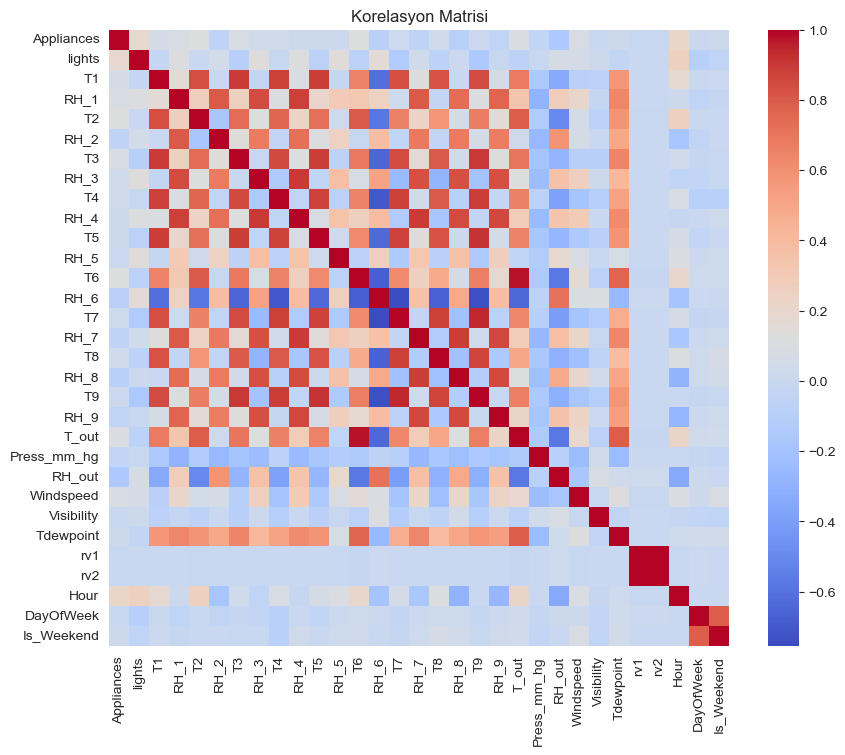

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()

In [34]:
df["Average_Indoor_Temperature"] = df[["T1","T2","T3","T4","T5","T7","T8","T9"]].mean(axis=1)

df["Delta_T"] = df["Average_Indoor_Temperature"] - df["T_out"]

df["Energy_Lag_1"] = df["Appliances"].shift(1)

df["Energy_Rolling_Mean"] = df["Appliances"].rolling(6).mean()

df["Energy_Rolling_Std"] = df["Appliances"].rolling(6).std()

df = df.dropna()

In [35]:
df["Expected_Energy"] = df.groupby("Hour")["Appliances"].transform("mean")

df["Energy_Diff"] = abs(df["Appliances"] - df["Expected_Energy"])

threshold = df["Energy_Diff"].mean() + 2 * df["Energy_Diff"].std()

df["is_anomaly"] = (df["Energy_Diff"] > threshold).astype(int)

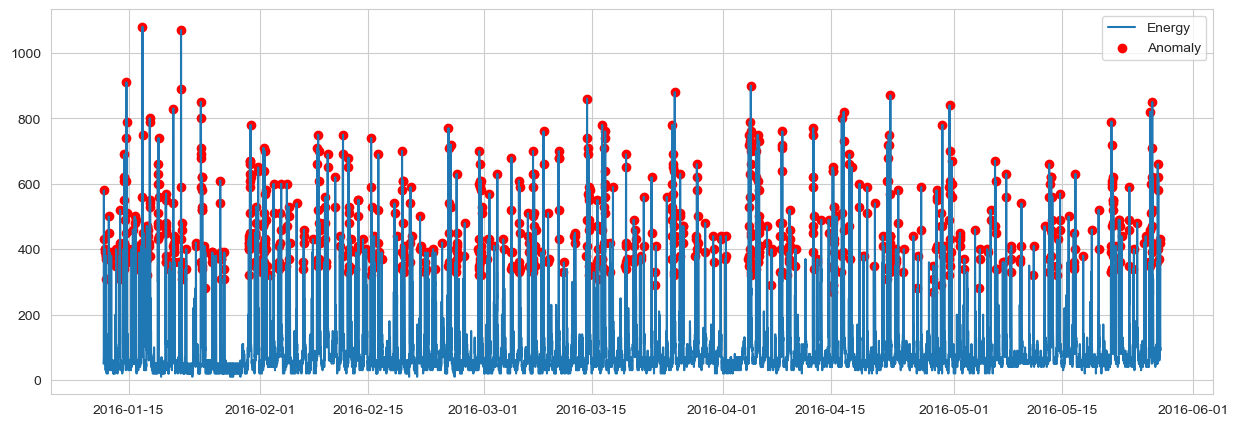

In [36]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["Appliances"], label="Energy")

anomalies = df[df["is_anomaly"] == 1]

plt.scatter(anomalies.index, anomalies["Appliances"], color="red", label="Anomaly")

plt.legend()
plt.show()

- Enerji tüketimi zaman serisi şeklindedir
- Saat bazlı belirgin davranış vardır
- Sıcaklık ile ilişki gözlemlenmiştir
- Basit threshold yöntemi ile anomali adayları bulunmuştur